In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

### Set up paths and import my DIR (deformable image registration) package
sys.path.insert(0, '/homebase/DL_projects/MUSA_dir_hj_2402')
import code_dir_hj_new as dirhj

### utils_dvf_disp.grid_plot_2d uses GPU
import torch
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
device = torch.device('cuda')

import utils_fig_basics as utils_fig_basics
import utils_new_quiver as utils_new_quiver


In [2]:
############################################################################
### MODIFY HERE
############################################################################
eval_dataset = '01intra_01'
# eval_dataset = '02inter_01'
# eval_dataset = '02inter_02'
# eval_dataset = '02inter_06'
# eval_dataset = '04inter_02'

ftype_ct = '.npy'
############################################################################

### For Fig4
dir_in_ct, list_fixed, list_moving = dirhj.utils_eval_dataset.get_eval_dataset(eval_dataset, INFO=True)
### For Fig7
# dir_in_ct, dir_in_seg_b, list_fixed, list_moving = dirhj.utils_eval_dataset.get_eval_dataset(eval_dataset, INFO=True, return_seg_b=True)

print(list_fixed[0:10])
print(list_moving[0:10])

assert len(list_fixed) == len(list_moving)
num_case = len(list_fixed)

print('num_case: ', num_case)

tic = time.time()
for idx_case in range(num_case):
    
    fname_fixed  = list_fixed[idx_case]  + ftype_ct
    fname_moving = list_moving[idx_case] + ftype_ct
    
    fname_suffix = '_f' + list_fixed[idx_case] + '_m' + list_moving[idx_case]
    
    print(idx_case+1, fname_fixed, fname_moving, fname_suffix)
    
    if idx_case+1 >= 10:
        break

tst_list:  /homebase/DL_projects/MUSA_dir_hj_2402/data_list/eval_list_v2/eval_list_01intra_01.txt
['0001_1', '0002_1', '0006_1', '0007_1', '0008_1', '0015_1', '0018_1']
['0001_2', '0002_2', '0006_2', '0007_2', '0008_2', '0015_2', '0018_2']
num_case:  7
1 0001_1.npy 0001_2.npy _f0001_1_m0001_2
2 0002_1.npy 0002_2.npy _f0002_1_m0002_2
3 0006_1.npy 0006_2.npy _f0006_1_m0006_2
4 0007_1.npy 0007_2.npy _f0007_1_m0007_2
5 0008_1.npy 0008_2.npy _f0008_1_m0008_2
6 0015_1.npy 0015_2.npy _f0015_1_m0015_2
7 0018_1.npy 0018_2.npy _f0018_1_m0018_2


In [3]:
############################################################################
### MODIFY HERE
############################################################################
FLAG_SAVE = False
# FLAG_SAVE = True

############################################################################

if FLAG_SAVE:
    
    # dir_out = './temp_results'
    dir_out = '/database/results/results_fig/results_0424_allfigures_run1/fig4_all_results'    
    os.makedirs(dir_out, exist_ok=True)
    
    dir_out_png = os.path.join(dir_out, eval_dataset)
    os.makedirs(dir_out_png, exist_ok=True)

In [4]:
arr_dir_result, info = utils_fig_basics.get_dir_result_as_array(eval_dataset)

model_names, strategy_names, deformed_name, dvf_name, ftype = info

print(model_names)
print(strategy_names)

row_titles = strategy_names
col_titles = model_names
nrow = len(strategy_names)
ncol = len(model_names)
row_titles = strategy_names
col_titles = model_names

print(nrow)
print(ncol)

print(arr_dir_result.shape)
print(arr_dir_result)

['VoxelMorph', 'Res-U-Net', 'LK-U-Net', 'TransMorph', 'Dual-PR-Net', 'LapIRN', 'Elastix']
['single-\nstage', '2-stage\n multires', '2-stage\n MUSA']
3
7
(3, 7)
[['/database/results/results_0424_run2/M01/S1_e1500/01intra_01/results_final'
  '/database/results/results_0424_run2/M02/S1_e1500/01intra_01/results_final'
  '/database/results/results_0424_run2/M03/S1_e1500/01intra_01/results_final'
  '/database/results/results_0424_run2/M04/S1_e1500/01intra_01/results_final'
  '/database/results/results_0424_run2/M05/S1_e1500/01intra_01/results_final'
  '/database/results/results_0424_run2/M06/S1_e1200/01intra_01/results_final'
  '/database/results/elastix/v1/1stage/01intra_01/results_final']
 ['/database/results/results_0424_run2/M01/S2-cont1000_e1000/01intra_01/results_final'
  '/database/results/results_0424_run2/M02/S2-cont1000_e1000/01intra_01/results_final'
  '/database/results/results_0424_run2/M03/S2-cont1000_e1000/01intra_01/results_final'
  '/database/results/results_0424_run2/M04/S2

0001_1.npy 0001_2.npy _f0001_1_m0001_2


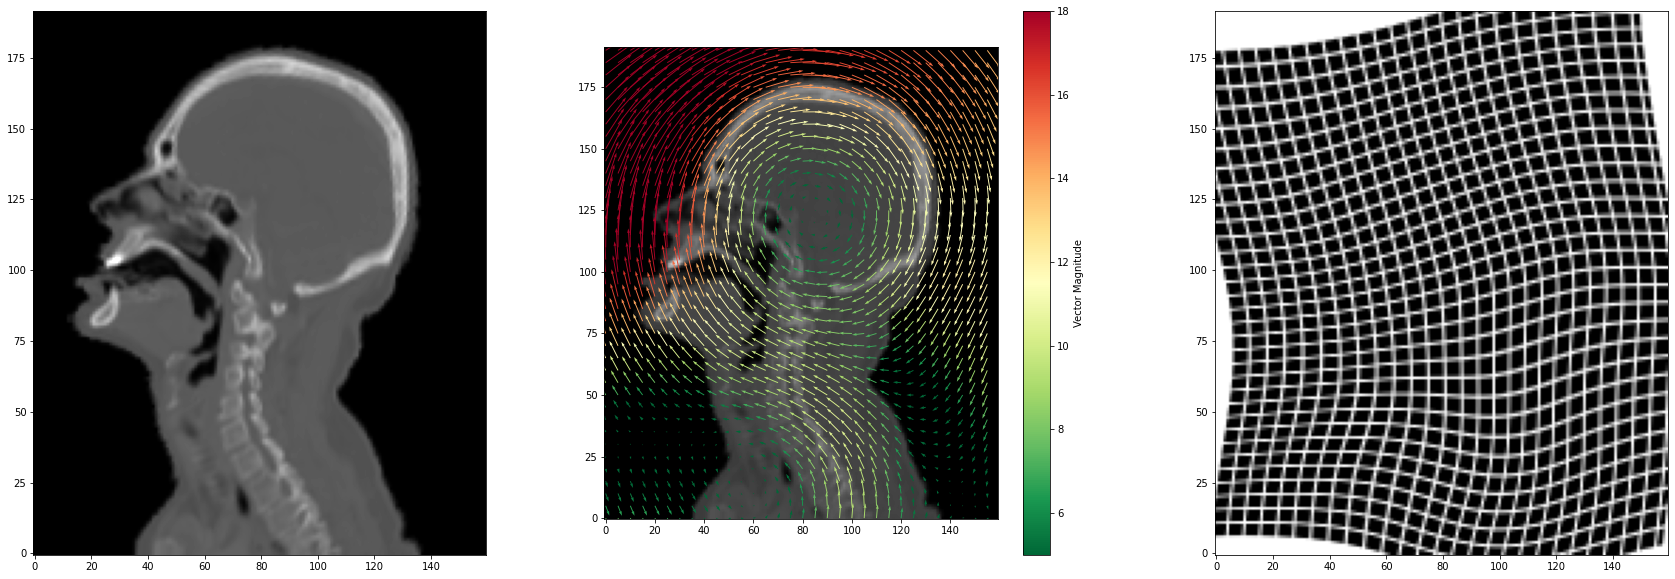

In [9]:
### vmin and vmax for CT
vmin = 0.
vmax = 0.75
###################################################################

scale = 2
fig, axs = plt.subplots(1, 3, figsize=(15*scale, 5*scale))


tic = time.time()
for idx_case in range(num_case):
    
    ###################################################
    ### Data loading
    ###################################################
    fname_fixed  = list_fixed[idx_case]  + ftype_ct
    fname_moving = list_moving[idx_case] + ftype_ct
    
    fname_suffix = '_f' + list_fixed[idx_case] + '_m' + list_moving[idx_case]
    
    print(fname_fixed, fname_moving, fname_suffix)
    
    
    ### Load all data for 1 patient
    path_moving = os.path.join(dir_in_ct, fname_moving)
    path_fixed  = os.path.join(dir_in_ct, fname_fixed)
    if ftype_ct == '.niigz':
        moving = dirhj.utils_io.load_nifti(path_moving)
        fixed  = dirhj.utils_io.load_nifti(path_fixed)
    elif ftype_ct == '.npy':
        moving = np.load(path_moving)
        fixed  = np.load(path_fixed)
        
    
    
    
    # deformed = np.load(os.path.join(arr_dir_result[idx_row, idx_col], deformed_name+fname_suffix+ftype))
    # dvf = np.load(os.path.join(arr_dir_result[idx_row, idx_col], dvf_name+fname_suffix+ftype))
    
    dir_result_elx = '/database/results/elastix/v1/1stage/01intra_01/results_final'
    deformed = np.load(os.path.join(dir_result_elx, deformed_name+fname_suffix+ftype))
    dvf = np.load(os.path.join(dir_result_elx, dvf_name+fname_suffix+ftype))
    
    deformed_disp = np.transpose(deformed[80,...], (1,0))
    
    # display deformed
    axs[0].imshow(deformed_disp, origin='lower', vmin=vmin, vmax=vmax, cmap='gray')
    # display deformed + dvf quiver
    # dirhj.utils_dvf_disp.quiver_plot_2d(deformed, dvf, orient='sag', idx_slc=80, ax=axs[1], crop_window=None, ds_step=5, scale=1, plot_option=None, color_code=False)
    # dirhj.utils_dvf_disp.quiver_plot_2d(deformed, dvf, orient='sag', idx_slc=80, ax=axs[1], crop_window=None, ds_step=5, scale=1, plot_option=None, color_code=True)
    # dirhj.utils_dvf_disp.quiver_plot_2d_new(deformed, dvf, orient='sag', idx_slc=80, ax=axs[1], crop_window=None, ds_step=5, scale=1, plot_option=None, color_code=True)
    
    color_code=True
    vmin_q = 5
    vmax_q = 18
    utils_new_quiver.quiver_plot_2d_new_v0(deformed, dvf, orient='sag', idx_slc=80, ax=axs[1], crop_window=None, ds_step=5, scale=1.5, plot_option=None, 
                                        color_code=True, vmin_q=vmin_q, vmax_q=vmax_q)
    
    # color_code=True
    # norm_minmax=None
    # norm_minmax='auto'
    # norm_minmax = (0, 1)
    # norm_percentile=None
    # # norm_percentile=(5,95)
    # utils_new_quiver.quiver_plot_2d_new_v1(deformed, dvf, orient='sag', idx_slc=80, ax=axs[1], crop_window=None, ds_step=5, scale=1.5, plot_option=None, 
    #                                     color_code=True, norm_minmax=norm_minmax, norm_percentile=norm_percentile)
    
    # quiver_plot_2d_new_new(deformed, dvf, orient='sag', idx_slc=80, ax=axs[1], crop_window=None, ds_step=5, scale=1.5, plot_option=None, color_code=True)
    # display dvf grid warp
    dirhj.utils_dvf_disp.grid_plot_2d(deformed, dvf, idx_slc=80, grid_spacing=5, grid_thickness=1, ax=axs[2])
        
    break